# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk 
import seaborn as sns
import plotly.express as px

In [3]:
salary_data = pd.read_csv('2025_salaries.csv', header = 1, encoding='latin-1')
stats = pd.read_csv('nba_2025.txt', sep=",", encoding='latin-1')

merged_data = pd.merge(salary_data, stats, on='Player')

In [4]:
#Drop variables that will not be needed or are duplicates
duplicates = merged_data[merged_data.duplicated(subset=['Player'], keep=False)]

# Keep the row with the highest G for each Player
df_final = (merged_data.sort_values('G', ascending=False).drop_duplicates(subset='Player', keep='first').reset_index(drop=True))
df_final['2025-26'] = df_final['2025-26'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)



### We now have our cleaned dataset called df_final
#### so lets run the clustering algo with our best guess for K 

In [5]:
# selecting only the numeric columns for clustering/columns that are relevant for clustering
df_final_cst = df_final.copy().drop(columns=['2025-26','Player', 'Tm', 'Team', 'Pos', 'Awards', 'Player-additional', 'Trp-Dbl']).fillna(0)

#Scaling the data with StandardScaler
scaler = sk.preprocessing.StandardScaler()
df_final_cst_scaled = scaler.fit_transform(df_final_cst)

In [6]:
#Run the clustering algo with your best guess for K
kmeans = sk.cluster.KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_final_cst_scaled)
# Add cluster labels to the original dataframe
df_final['Cluster'] = kmeans.labels_ 

In [7]:
#View the results
print("Cluster Centers: ")
print(kmeans.cluster_centers_)

print("\nCluster Labels for each observation:")
print(kmeans.labels_)

print("\nWithin-cluster sum of squares (WCSS):")
print(kmeans.inertia_)

Cluster Centers: 
[[-4.03537669e-01  8.42326235e-04  4.34948117e-01  8.90319094e-02
   3.75852513e-01  1.02284546e-01  1.88462517e-01 -2.37774344e-01
   4.84102360e-01  4.90000054e-01  2.84078189e-01 -1.02490641e-01
  -6.14414095e-02 -1.19813332e-01 -5.63879549e-03 -3.32483591e-02
  -5.41444884e-02  2.67900019e-01 -1.70989454e-01  4.28298469e-02
  -2.31056386e-02  2.00516313e-01  4.07246411e-01 -1.34301263e-01
   1.41554600e-01  3.15102254e-01  1.30176849e-01]
 [-3.18012042e-01 -1.29043933e-01  5.51364437e-01  3.11701665e-01
   3.21874447e-01  2.19103239e-01 -5.39649420e-02  1.34121672e+00
  -6.45117109e-01 -6.78312757e-01 -5.23686043e-01  5.96438955e-01
   3.93894487e-01  8.12425489e-01  8.98997448e-01  2.65443655e-02
   1.84110792e-01 -5.36835758e-01  1.97028438e+00  9.59072823e-01
   1.34340293e+00 -2.87704945e-01  1.03655339e-01  1.41057233e+00
  -3.08893559e-03  7.54099472e-01  7.54351163e-02]
 [-1.32766041e+00  1.21516950e-01  7.47177428e-01  1.39724435e+00
   1.33043423e+00  1.6

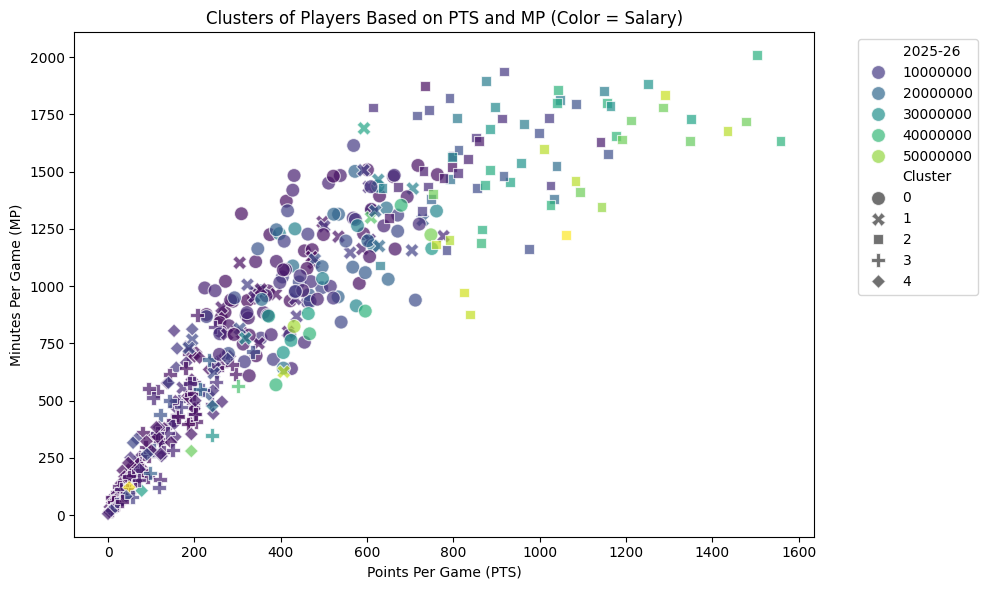

In [8]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='PTS', y='MP', 
                hue='2025-26', style='Cluster', 
                palette='viridis', s=100, alpha=0.7)
plt.xlabel('Points Per Game (PTS)')
plt.ylabel('Minutes Per Game (MP)')
plt.title('Clusters of Players Based on PTS and MP (Color = Salary)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
fig = px.scatter_3d(
    df_final, x='PTS', y='MP', z='G',
    color='2025-26',
    symbol='Cluster',
    title='Points vs Minutes vs Games by Cluster (Color = Salary)',
    labels={'PTS': 'Points Per Game', 
            'MP': 'Minutes Per Game', 
            'G': 'Games Played',
            '2025-26': 'Salary'}
)
fig.show(renderer="browser")

In [ ]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

In [ ]:
#Visualize the results of the elbow method

In [ ]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results

In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Use the model to select players for Mr. Rooney to consider

In [ ]:
#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.